<a href="https://colab.research.google.com/github/Pokam-Abukakar/sla-model-api./blob/main/Predict_SLA_breach_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resources

In [ ]:
!pip install xgboost imbalanced-learn shap --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
roc_auc_score, roc_curve, recall_score,
precision_score, f1_score, ConfusionMatrixDisplay)
import shap
sns.set_style('whitegrid')
print('All libraries loaded successfully')

All libraries loaded successfully


Installing the `xgboost`, `imbalanced-learn`, and `shap` libraries silently. Importing a comprehensive set of Python libraries essential for data manipulation, visualization, and machine learning, including `numpy`, `pandas`, `matplotlib`, `seaborn`, and various modules from `sklearn` for model building and evaluation. Warnings are also suppressed for cleaner output.

*   **`numpy`**: Numerical computing with powerful array objects.
*   **`pandas`**: Data manipulation and analysis, especially with DataFrames.
*   **`matplotlib.pyplot`**: Creating static, interactive, and animated visualizations.
*   **`seaborn`**: Statistical data visualization based on matplotlib.
*   **`warnings`**: Controlling warning messages.
*   **`sklearn.linear_model.LogisticRegression`**: Implements logistic regression for classification.
*   **`sklearn.ensemble.RandomForestClassifier`**: Implements random forest algorithm for classification.
*   **`xgboost.XGBClassifier`**: Implements XGBoost for gradient boosting classification.
*   **`sklearn.preprocessing.StandardScaler`**: Standardizes features by removing the mean and scaling to unit variance.
*   **`sklearn.preprocessing.LabelEncoder`**: Encodes target labels with values between 0 and n_classes-1.
*   **`sklearn.model_selection.train_test_split`**: Splits arrays or matrices into random train and test subsets.
*   **`sklearn.model_selection.cross_val_score`**: Evaluates a score by cross-validation.
*   **`sklearn.model_selection.StratifiedKFold`**: Provides train/test indices to split data in train/test sets.
*   **`sklearn.metrics`**: Provides various metrics for model evaluation, including:
    *   **`classification_report`**: Builds a text report showing the main classification metrics.
    *   **`confusion_matrix`**: Computes confusion matrix to evaluate the accuracy of a classification.
    *   **`roc_auc_score`**: Computes Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores.
    *   **`roc_curve`**: Computes Receiver operating characteristic (ROC).
    *   **`recall_score`**: Computes the recall.
    *   **`precision_score`**: Computes the precision.
    *   **`f1_score`**: Computes the F1 score.
    *   **`ConfusionMatrixDisplay`**: Renders confusion matrices.
*   **`shap`**: Explains individual predictions of machine learning models.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

output_path = '/content/drive/MyDrive/incident_event_log_saved.csv'

# The line below caused a NameError because df_raw is not yet defined.
# df_raw.to_csv(output_path, index=False, sep=';')
# print(f'DataFrame saved to: {output_path}')

Mounted at /content/drive


Mounting Google Drive to access files; the `output_path` variable is defined with the file's location.

In [ ]:
df_raw = pd.read_csv(output_path, sep=';')
print(f'Total event rows: {len(df_raw):,}')
print(f'Unique tickets: {df_raw["number"].nunique():,}')
print(f'Columns: {df_raw.shape[1]}')
df_raw.head()

Total event rows: 141,712
Unique tickets: 24,918
Columns: 36


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29.02.2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29.02.2016 11:29,05.03.2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29.02.2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29.02.2016 11:29,05.03.2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29.02.2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29.02.2016 11:29,05.03.2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29.02.2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29.02.2016 11:29,05.03.2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29.02.2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,01.03.2016 09:52,06.03.2016 10:00


This dataset, `df_raw`, contains event logs related to incidents, with each row representing an event. It includes information such as incident state, reassignment counts, SLA status, and various timestamps. There are 141,712 event rows and 24,918 unique incident tickets, with 36 columns providing detailed attributes for each event.

In [ ]:

df_sorted = df_raw.sort_values(['number', 'sys_mod_count'])
# First snapshot per ticket (features only - no outcome leakage)
df_first = df_sorted.groupby("number").first().reset_index()
# Last snapshot per ticket (ground truth label)
df_last = df_sorted.groupby("number").last().reset_index()[["number", "made_sla"]]
# Merge: features from first, label from last
df = df_first.merge(df_last, on="number", suffixes=('_first', '_final'))
# Invert: sla_breached = 1 means BAD (breach) - the event we want to predict
df["sla_breached"] = (df["made_sla_final"] == False).astype(int)
print(f'Modelling dataset shape: {df.shape}')
print(f'SLA breach rate: {df["sla_breached"].mean():.1%}')

Modelling dataset shape: (24918, 38)
SLA breach rate: 36.6%


The event log has multiple rows per ticket.
FIRST snapshot = features available at ticket creation (what the model sees).
LAST snapshot = final outcome: was SLA met or breached?
Sort by modification count (chronological order within each ticket)

In [ ]:
# Replace "?" with NaN so pandas recognises them
df.replace('?', np.nan, inplace=True)
# Count missing per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_%",
ascending=False)
print(missing_report)

                  missing_count  missing_%
caused_by                 24916      100.0
vendor                    24903       99.9
cmdb_ci                   24867       99.8
rfc                       24820       99.6
problem_id                24677       99.0
sys_created_by            11495       46.1
sys_created_at            11495       46.1
assigned_to                7140       28.7
u_symptom                  5735       23.0
resolved_at                1556        6.2
assignment_group            906        3.6
opened_by                   714        2.9
resolved_by                  99        0.4
closed_code                 107        0.4
subcategory                  69        0.3
location                     52        0.2
category                     39        0.2
caller_id                     3        0.0


Addressing missing data by replacing '?' values with `np.nan` (Not a Number) to ensure proper handling by pandas. Generating a report on missing values, showing the count and percentage of missing entries for each column in the DataFrame, sorted by the percentage of missing data.

In [ ]:
dupes = df[df.duplicated(subset='number', keep=False)]
print(f'Duplicate ticket rows: {len(dupes)}')
print('(Expected: 0 - each ticket appears once after groupby)')

Duplicate ticket rows: 0
(Expected: 0 - each ticket appears once after groupby)


Checking for duplicate rows based on the 'number' column within the `df` DataFrame. Printing the count of duplicate ticket rows, expecting zero duplicates to confirm that each incident ticket is uniquely represented after the aggregation steps.

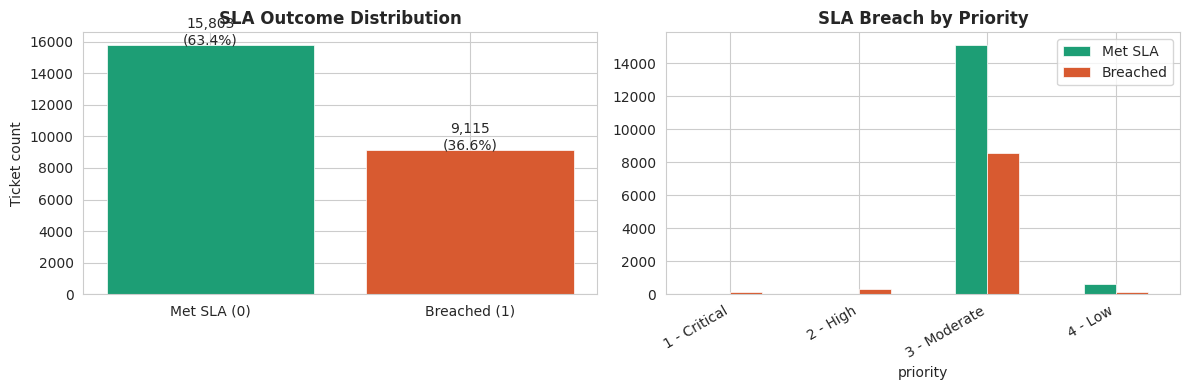


Breached: 9,115 (36.6%)
Met SLA: 15,803 (63.4%)

® Imbalance detected. Will use class_weight=balanced in all models.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Count plot
counts = df["sla_breached"].value_counts()
axes[0].bar(["Met SLA (0)", "Breached (1)"], counts.values,
color=["#1D9E75", "#D85A30"], edgecolor="white", linewidth=0.5)
axes[0].set_title("SLA Outcome Distribution", fontweight="bold")
axes[0].set_ylabel("Ticket count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=10)
# Priority breakdown by SLA outcome
priority_sla = df.groupby(["priority", "sla_breached"]).size().unstack()
priority_sla.plot(kind="bar", ax=axes[1], color=["#1D9E75","#D85A30"],
edgecolor="white", linewidth=0.5)
axes[1].set_title("SLA Breach by Priority", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend(["Met SLA", "Breached"])
plt.tight_layout()
plt.show()
print(f'\nBreached: {counts[1]:,} ({counts[1]/len(df):.1%})')
print(f'Met SLA: {counts[0]:,} ({counts[0]/len(df):.1%})')
print('\n® Imbalance detected. Will use class_weight=balanced in all models.')

Visualizing the distribution of SLA outcomes and their breakdown by priority. The left plot shows the overall count and percentage of tickets that met or breached SLA, while the right plot illustrates how SLA breach rates vary across different priority levels.

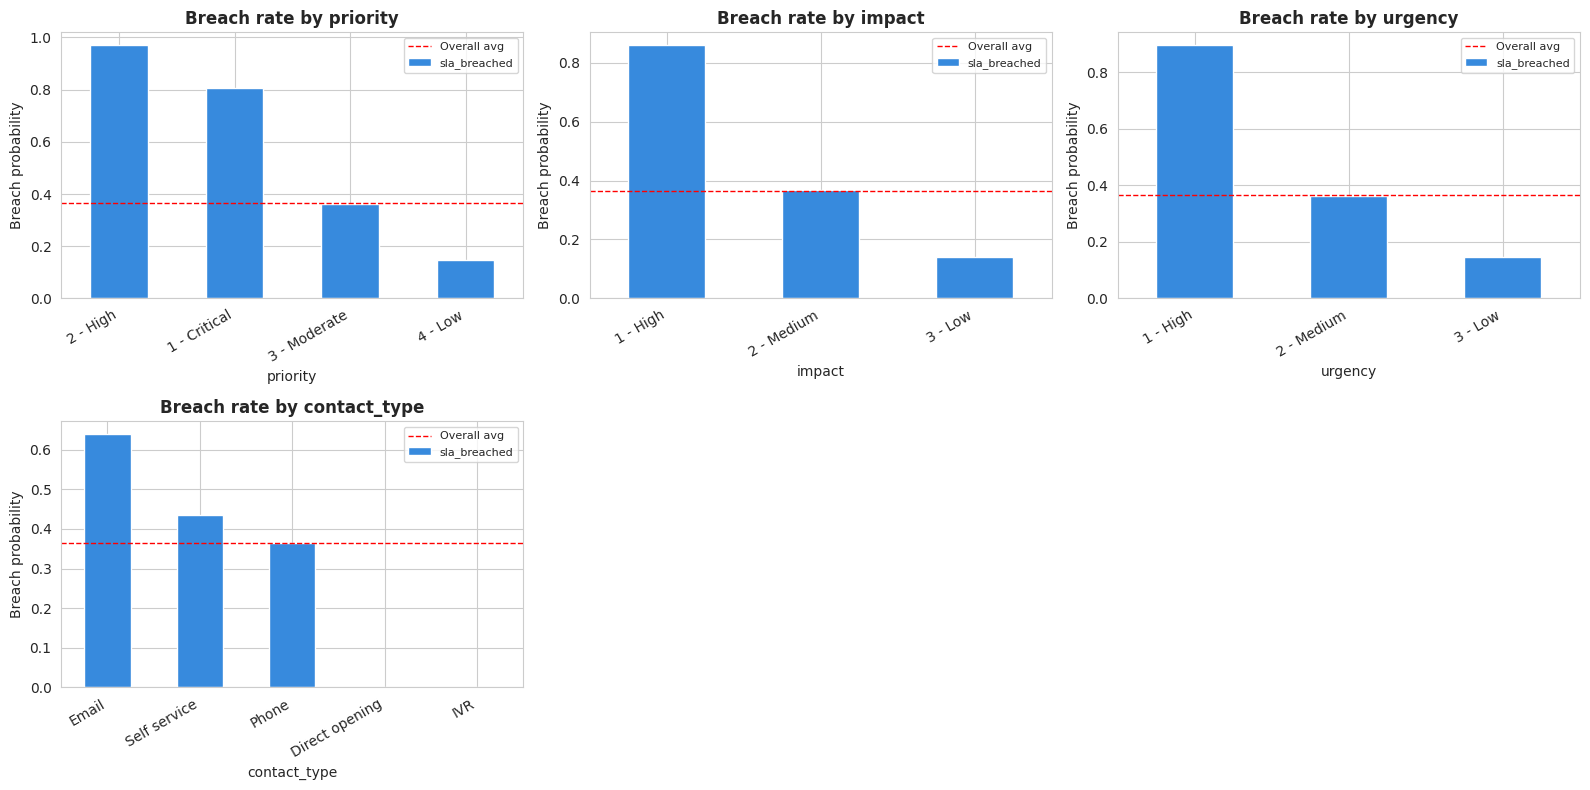

Bar charts show which categories have highest breach rates ® strong predictors


In [ ]:
cat_features = ['priority', 'impact', 'urgency', 'contact_type'] # 'category' removed
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    breach_rate = df.groupby(col)["sla_breached"].mean().sort_values(ascending=False)
    breach_rate.plot(kind="bar", ax=axes[i], color="#378ADD", edgecolor="white")
    axes[i].set_title(f"Breach rate by {col}", fontweight="bold")
    axes[i].set_ylabel("Breach probability")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha="right")
    axes[i].axhline(df["sla_breached"].mean(), color="red",
                    linestyle="--", linewidth=1, label="Overall avg")
    axes[i].legend(fontsize=8)
axes[4].axis("off") # Turn off the unused 5th subplot
axes[5].axis("off") # Turn off the unused 6th subplot
plt.tight_layout()
plt.show()
print('Bar charts show which categories have highest breach rates ® strong predictors')

Generating bar charts to visualize the SLA breach rate across different categorical features such as 'priority', 'impact', 'urgency', and 'contact_type'. Each chart includes a horizontal dashed line indicating the overall average breach rate for comparison, helping identify categories with higher or lower breach probabilities.

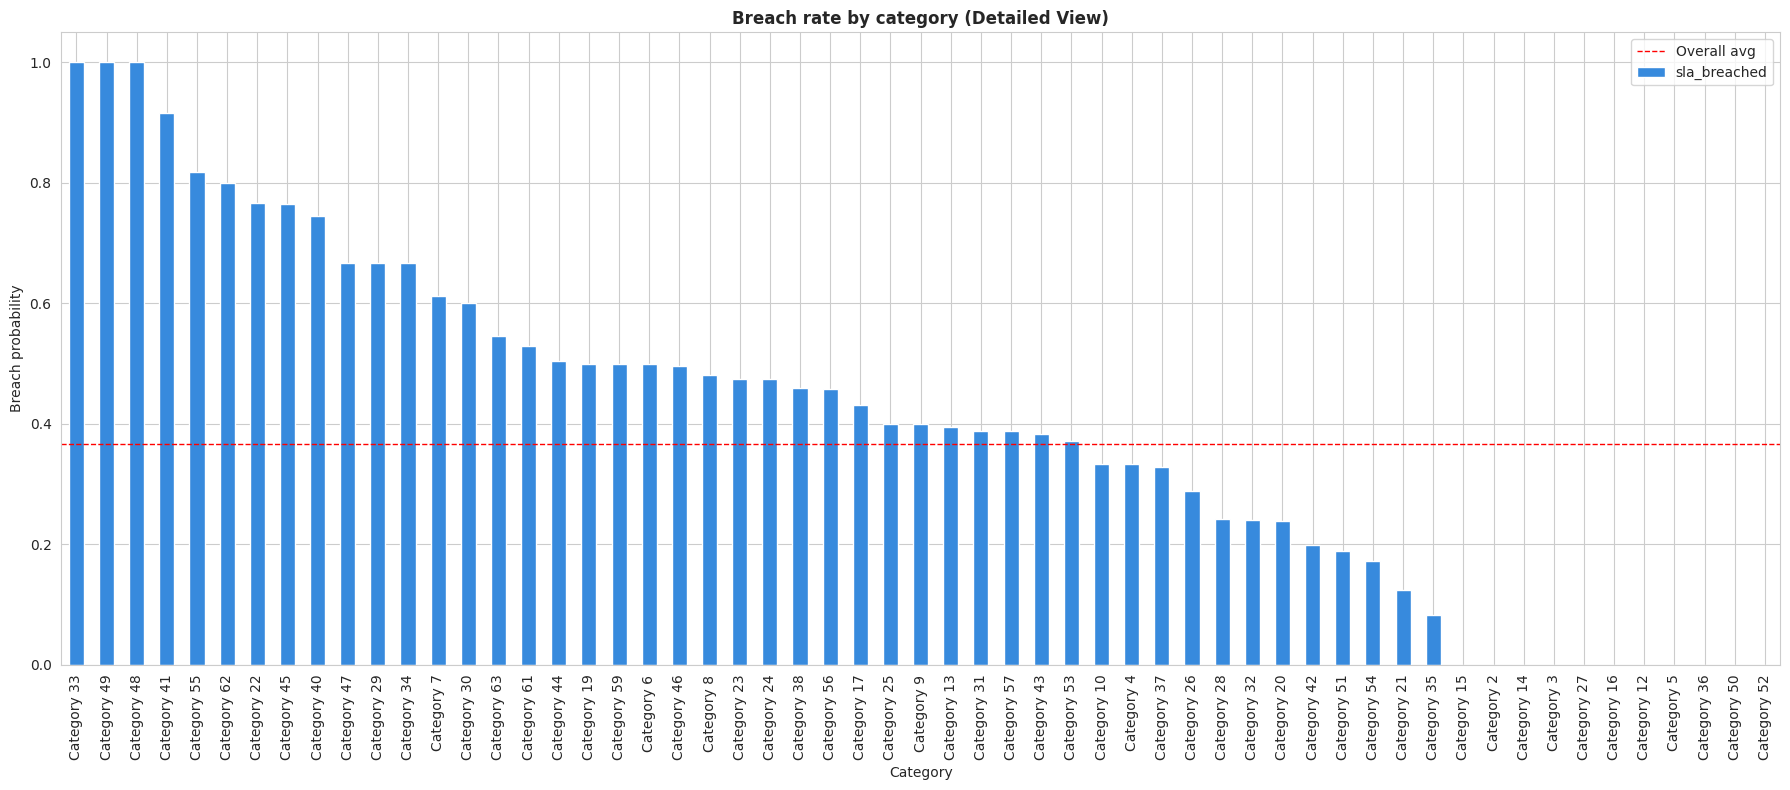

In [ ]:
plt.figure(figsize=(18, 8)) # Enlarge figure size
breach_rate_category = df.groupby('category')['sla_breached'].mean().sort_values(ascending=False)
breach_rate_category.plot(kind='bar', color='#378ADD', edgecolor='white')
plt.title('Breach rate by category (Detailed View)', fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Breach probability')
plt.xticks(rotation=90, ha='center') # Rotate labels for better readability
plt.axhline(df['sla_breached'].mean(), color='red', linestyle='--', linewidth=1, label='Overall avg')
plt.legend()
plt.tight_layout()
plt.show()

Providing a detailed view of the SLA breach rate for each 'category' in the dataset. Generating a bar chart displaying categories sorted by their breach probability, alongside the overall average breach rate, to highlight categories that are particularly prone to SLA breaches.

In [ ]:
# Time elapsed features are powerful predictors of SLA breach risk
# A ticket that was opened 3 days ago with no update is high risk
date_cols = ['opened_at', 'sys_created_at', 'sys_updated_at', 'resolved_at', 'closed_at']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%d.%m.%Y %H:%M', errors='coerce')
# Feature: time from open to last update (how stale is the ticket?)
df["hours_open_to_update"] = (
    (df["sys_updated_at"] - df["opened_at"]).dt.total_seconds() / 3600
).clip(lower=0)
# Feature: hour of day ticket was opened (morning vs evening)
df["open_hour"] = df["opened_at"].dt.hour
# Feature: day of week (weekends may have less coverage)
df["open_dayofweek"] = df["opened_at"].dt.dayofweek
# Feature: is it a weekend? (reduced staff = higher breach risk)
df["is_weekend"] = (df["open_dayofweek"] >= 5).astype(int)
print('Time features created:')
print(df[['hours_open_to_update','open_hour','open_dayofweek','is_weekend']].describe())

Time features created:
       hours_open_to_update     open_hour  open_dayofweek    is_weekend
count          24918.000000  24918.000000    24918.000000  24918.000000
mean               0.086763     11.885826        1.963360      0.048238
std                0.243848      4.102111        1.588648      0.214274
min                0.000000      0.000000        0.000000      0.000000
25%                0.000000      9.000000        1.000000      0.000000
50%                0.016667     11.000000        2.000000      0.000000
75%                0.100000     15.000000        3.000000      0.000000
max               19.100000     23.000000        6.000000      1.000000


Creating new time-based features from existing datetime columns. Calculating the time elapsed from when a ticket was opened to its last update (`hours_open_to_update`), extracting the hour of the day (`open_hour`) and day of the week (`open_dayofweek`) a ticket was opened, and determining if the opening day was a weekend (`is_weekend`). These features are crucial for predicting SLA breaches.

Cell 10 - Define the feature set and drop unusable columns

In [ ]:
# DROP these column categories:
# 1. Identifier columns (ticket number, person names) - not generalisable
# 2. Near-empty columns (>95% missing) - too sparse to be useful
# 3. Leaky columns (resolved_at, closed_at, closed_code) - not known at prediction time
# 4. Redundant ID-like columns (sys_created_by, sys_updated_by)
FEATURES = [
# Ticket characteristics (known at creation)
'impact', 'urgency', 'priority', 'contact_type',
'category', 'knowledge', 'u_priority_confirmation',
'notify', 'reassignment_count', 'reopen_count', 'sys_mod_count',
# Assignment info
'assignment_group',
# Engineered time features
'hours_open_to_update', 'open_hour', 'open_dayofweek', 'is_weekend',
]
TARGET = "sla_breached"
# Build modelling dataframe
df_model = df[FEATURES + [TARGET]].copy()
print(f'Modelling dataframe: {df_model.shape}')
print(f'Features: {len(FEATURES)}')
df_model.head()

Modelling dataframe: (24918, 17)
Features: 16


,impact,urgency,priority,contact_type,category,knowledge,u_priority_confirmation,notify,reassignment_count,reopen_count,sys_mod_count,assignment_group,hours_open_to_update,open_hour,open_dayofweek,is_weekend,sla_breached
0,2 - Medium,2 - Medium,3 - Moderate,Phone,Category 55,True,False,Do Not Notify,0,0,0,Group 56,0.116667,1,0,0,0
1,2 - Medium,2 - Medium,3 - Moderate,Phone,Category 40,True,False,Do Not Notify,0,0,0,Group 70,0.283333,4,0,0,0
2,2 - Medium,2 - Medium,3 - Moderate,Phone,Category 20,True,False,Do Not Notify,0,0,0,Group 70,0.266667,6,0,0,0
3,2 - Medium,2 - Medium,3 - Moderate,Phone,Category 9,True,False,Do Not Notify,0,0,0,Group 25,0.066667,6,0,0,0
4,2 - Medium,2 - Medium,3 - Moderate,Phone,Category 53,True,False,Do Not Notify,0,0,0,Group 70,0.466667,6,0,0,1


Defining the set of features (`FEATURES`) to be used for modeling, excluding identifier columns, near-empty columns, leaky columns, and redundant ID-like columns. Constructing `df_model`, a new DataFrame containing only these selected features and the target variable `sla_breached`.

In [ ]:
# Fill missing values with sensible defaults before encoding
# Categorical: fill with "Unknown" (preserves the fact that it was missing)
cat_cols = df_model.select_dtypes('object').columns.tolist()
for col in cat_cols:
    df_model[col].fillna("Unknown", inplace=True)
# Numerical: fill with median (robust to outliers)
num_cols = df_model.select_dtypes('number').columns.drop(TARGET).tolist()
for col in num_cols:
    df_model[col].fillna(df_model[col].median(), inplace=True)
# Verify no nulls remain
print('Remaining nulls:', df_model.isnull().sum().sum())
print('® Expected: 0')

Remaining nulls: 0
® Expected: 0


Handling missing values in the `df_model` DataFrame. Categorical columns are filled with 'Unknown' to preserve the information that the value was missing, while numerical columns are filled with their median values, a robust strategy against outliers. Finally, verifying that no null values remain in the DataFrame.

Cell 12 - Encode categorical features

In [ ]:
# ML algorithms require numbers. We use get_dummies (one-hot encoding).
# drop_first=True avoids perfect multicollinearity (the dummy variable trap).
# Ordinal encoding for priority/impact/urgency (they have natural order)
ordinal_map = {
'1 - Critical': 4, '1 - High': 4,
'2 - High': 3, '2 - Medium': 3,
'3 - Moderate': 2, '3 - Low': 2,
'4 - Low': 1,
'Unknown': 0
}
for col in ['priority', 'impact', 'urgency']:
    df_model[col] = df_model[col].map(ordinal_map).fillna(0).astype(int)
# Boolean columns to int
for col in ['knowledge', 'u_priority_confirmation']:
    df_model[col] = df_model[col].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)
# Nominal categoricals: one-hot encode
nominal_cols = ['contact_type', 'category', 'assignment_group', 'notify']
df_encoded = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)
print(f'Features after encoding: {df_encoded.shape[1] - 1}')
print(f'Total rows: {len(df_encoded):,}')

Features after encoding: 143
Total rows: 24,918


Transforming categorical features into a numerical format suitable for machine learning algorithms. Applying ordinal encoding to 'priority', 'impact', and 'urgency' based on their inherent order, converting boolean columns to integers, and using one-hot encoding (`pd.get_dummies`) for nominal categorical features to avoid the dummy variable trap.

In [ ]:
# Outliers in numeric features can skew linear models substantially.
# We cap at 1.5x IQR rather than drop, to preserve data volume.
num_feature_cols = ['hours_open_to_update', 'reassignment_count',
'reopen_count', 'sys_mod_count']
before = len(df_encoded)
for col in num_feature_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_encoded[col] = df_encoded[col].clip(lower=lower, upper=upper)
print(f'Rows before: {before:,} | Rows after (capped, not dropped): {len(df_encoded):,}')
print('Numeric features capped at IQR bounds.')

Rows before: 24,918 | Rows after (capped, not dropped): 24,918
Numeric features capped at IQR bounds.


Addressing outliers in selected numerical features by capping their values within 1.5 times the Interquartile Range (IQR). This approach helps to mitigate the influence of extreme values without removing any data, ensuring that the model is not unduly skewed by outliers.

### Split Data and Scale Numerical Features

In [ ]:
# ALWAYS split before any transformation - this is a data leakage rule
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]
# stratify=y ensures both train and test have same class distribution
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y # preserves the 36.6% breach rate in both splits
)
print(f'Training set: {X_train.shape[0]:,} rows | Breach rate: {y_train.mean():.1%}')
print(f'Test set: {X_test.shape[0]:,} rows | Breach rate: {y_test.mean():.1%}')
# Scale AFTER split - fit only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit + transform
X_test_scaled = scaler.transform(X_test) # transform only - NO fit
print('\nScaling complete. Test set was NEVER used to fit the scaler.')

Training set: 19,934 rows | Breach rate: 36.6%
Test set: 4,984 rows | Breach rate: 36.6%

Scaling complete. Test set was NEVER used to fit the scaler.


Preparing the data for model training by splitting it into training and testing sets while preserving the class distribution of the target variable (`stratify=y`). Scaling the numerical features using `StandardScaler`, fitting only on the training data to prevent data leakage and ensure the model generalizes well to unseen data.

In [ ]:
# class_weight=balanced automatically handles the 36.6% / 63.4% imbalance
# It upweights breach examples so the model does not ignore the minority class
lr = LogisticRegression(
class_weight='balanced',
max_iter=1000,
random_state=42
)
# 5-fold stratified cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_recall = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="recall")
cv_precision = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="precision")
cv_f1 = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="f1")
cv_auc = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
print('=== Baseline: Logistic Regression (5-fold CV on training set) ===')
print(f'Recall: {cv_recall.mean():.3f} +/- {cv_recall.std():.3f}')
print(f'Precision: {cv_precision.mean():.3f} +/- {cv_precision.std():.3f}')
print(f'F1-Score: {cv_f1.mean():.3f} +/- {cv_f1.std():.3f}')
print(f'AUC-ROC: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}')
# Fit final baseline on full training set
lr.fit(X_train_scaled, y_train)
print('\nBaseline model fitted.')

=== Baseline: Logistic Regression (5-fold CV on training set) ===
Recall: 0.682 +/- 0.010
Precision: 0.621 +/- 0.007
F1-Score: 0.650 +/- 0.006
AUC-ROC: 0.804 +/- 0.007

Baseline model fitted.


Initializing and training a Logistic Regression model with `class_weight='balanced'` to handle class imbalance. Performing 5-fold stratified cross-validation on the training set to evaluate the model's performance using metrics like recall, precision, F1-score, and AUC-ROC, providing a robust estimate of its generalization ability.

=== Baseline Test Set Performance ===
              precision    recall  f1-score   support

     Met SLA       0.80      0.75      0.77      3161
    Breached       0.60      0.67      0.64      1823

    accuracy                           0.72      4984
   macro avg       0.70      0.71      0.70      4984
weighted avg       0.73      0.72      0.72      4984



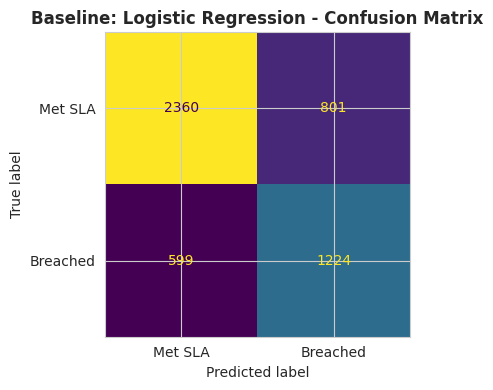


Baseline AUC-ROC on test: 0.794


In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print('=== Baseline Test Set Performance ===')
print(classification_report(y_test, y_pred_lr,
target_names=["Met SLA", "Breached"]))
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
y_test, y_pred_lr,
display_labels=["Met SLA", "Breached"],
colorbar=False, ax=ax
)
ax.set_title("Baseline: Logistic Regression - Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()
print(f'\nBaseline AUC-ROC on test: {roc_auc_score(y_test, y_prob_lr):.3f}')

Evaluating the trained Logistic Regression model's performance on the unseen test set. Generating a classification report detailing precision, recall, and F1-score for each class, displaying a confusion matrix for visual assessment of predictions, and calculating the AUC-ROC score to measure the model's ability to distinguish between classes.

In [ ]:
# scale_pos_weight handles class imbalance for XGBoost
# It is equivalent to class_weight=balanced in sklearn
# Calculate weight for positive class (breach)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f'scale_pos_weight = {scale_weight:.2f} (auto-balances the imbalance)')
xgb = XGBClassifier(
n_estimators=300,
max_depth=5,
learning_rate=0.05,
subsample=0.8,
colsample_bytree=0.8,
scale_pos_weight=scale_weight,
random_state=42,
eval_metric='logloss',
use_label_encoder=False,
tree_method='hist', # faster on Colab CPU
)
# Cross-validation
cv_recall_xgb = cross_val_score(xgb, X_train_scaled, y_train, cv=cv, scoring="recall")
cv_auc_xgb = cross_val_score(xgb, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
cv_f1_xgb = cross_val_score(xgb, X_train_scaled, y_train, cv=cv, scoring="f1")
print('\n=== XGBoost (5-fold CV on training set) ===')
print(f'Recall: {cv_recall_xgb.mean():.3f} +/- {cv_recall_xgb.std():.3f}')
print(f'F1-Score: {cv_f1_xgb.mean():.3f} +/- {cv_f1_xgb.std():0.3f}')
print(f'AUC-ROC: {cv_auc_xgb.mean():.3f} +/- {cv_auc_xgb.std():.3f}')
# Fit on full training set
xgb.fit(X_train_scaled, y_train)
print('\nXGBoost model fitted on full training set.')

scale_pos_weight = 1.73 (auto-balances the imbalance)

=== XGBoost (5-fold CV on training set) ===
Recall: 0.797 +/- 0.006
F1-Score: 0.683 +/- 0.007
AUC-ROC: 0.828 +/- 0.006

XGBoost model fitted on full training set.


Initializing and training an XGBoost classifier, explicitly addressing class imbalance using `scale_pos_weight`. Performing 5-fold stratified cross-validation on the training set to assess the model's recall, F1-score, and AUC-ROC, ensuring the model's robustness and generalization capability before final fitting.

=== XGBoost Test Set Performance ===
              precision    recall  f1-score   support

     Met SLA       0.84      0.68      0.75      3161
    Breached       0.59      0.78      0.67      1823

    accuracy                           0.72      4984
   macro avg       0.71      0.73      0.71      4984
weighted avg       0.75      0.72      0.72      4984



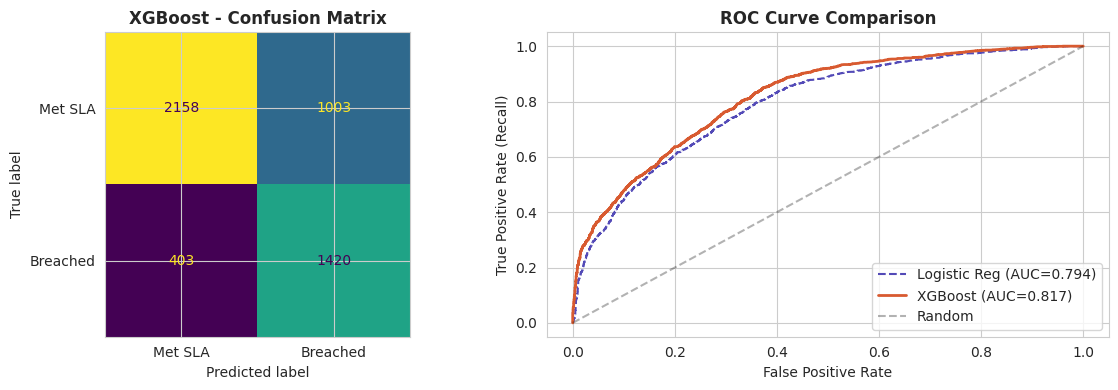

In [ ]:
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
print('=== XGBoost Test Set Performance ===')
print(classification_report(y_test, y_pred_xgb,
target_names=["Met SLA", "Breached"]))
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
y_test, y_pred_xgb,
display_labels=["Met SLA", "Breached"],
colorbar=False, ax=axes[0]
)
axes[0].set_title("XGBoost - Confusion Matrix", fontweight="bold")
# ROC curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[1].plot(fpr_lr, tpr_lr, label=f"Logistic Reg (AUC={roc_auc_score(y_test,y_prob_lr):.3f})",
color="#534AB7", linestyle="--")
axes[1].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={roc_auc_score(y_test,y_prob_xgb):.3f})",
color="#D85A30", linewidth=2)
axes[1].plot([0,1],[0,1], "k--", alpha=0.3, label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate (Recall)")
axes[1].set_title("ROC Curve Comparison", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.show()

Evaluating the trained XGBoost model on the test set, presenting a classification report, a confusion matrix, and a comparative ROC curve alongside the Logistic Regression model. This comprehensive evaluation highlights the model's strengths in predicting SLA breaches and its overall discriminative power.

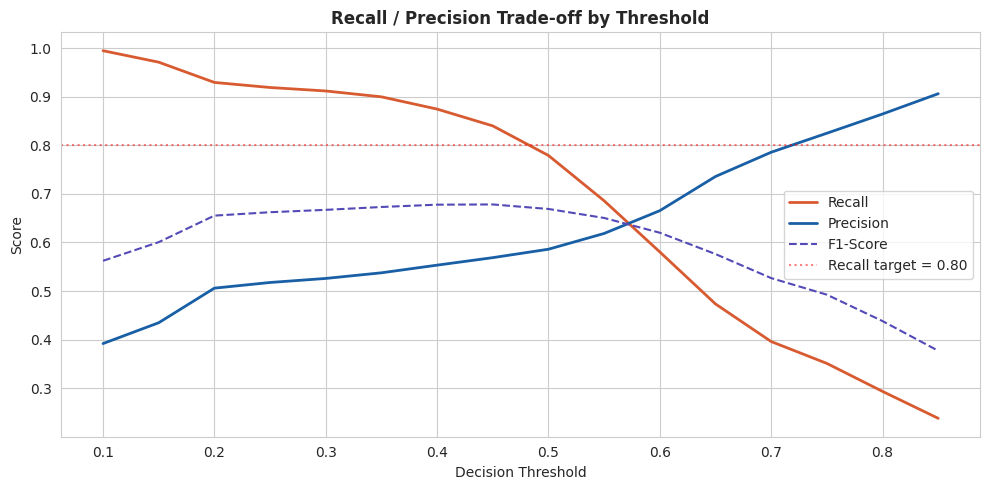


Recommended threshold: 0.45
 Recall: 0.840
 Precision: 0.569
 F1-Score: 0.678


In [ ]:
# Default threshold = 0.5. For high-recall use cases, we lower it.
# This trades precision (more false alarms) for recall (fewer missed breaches).
thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
    preds = (y_prob_xgb >= t).astype(int)
    results.append({
        'threshold': t,
        'recall': recall_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds)
    })
thresh_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall', color='#D85A30', linewidth=2)
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='#185FA5', linewidth=2)
plt.plot(thresh_df['threshold'], thresh_df['f1'], label='F1-Score', color='#534AB7', linestyle="--", linewidth=1.5)
plt.axhline(0.8, color='red', linestyle=':', alpha=0.5, label='Recall target = 0.80')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Recall / Precision Trade-off by Threshold', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Find threshold where recall >= 0.80
best = thresh_df[thresh_df['recall'] >= 0.80].sort_values('precision', ascending=False).iloc[0]
print(f'\nRecommended threshold: {best["threshold"]:.2f}')
print(f' Recall: {best["recall"]:.3f}')
print(f' Precision: {best["precision"]:.3f}')
print(f' F1-Score: {best["f1"]:.3f}')

Analyzing the trade-off between recall, precision, and F1-score by varying the decision threshold for the XGBoost model. Visualizing how these metrics change across different thresholds and recommending an optimal threshold that achieves a target recall of at least 0.80, prioritizing the identification of as many actual breaches as possible.

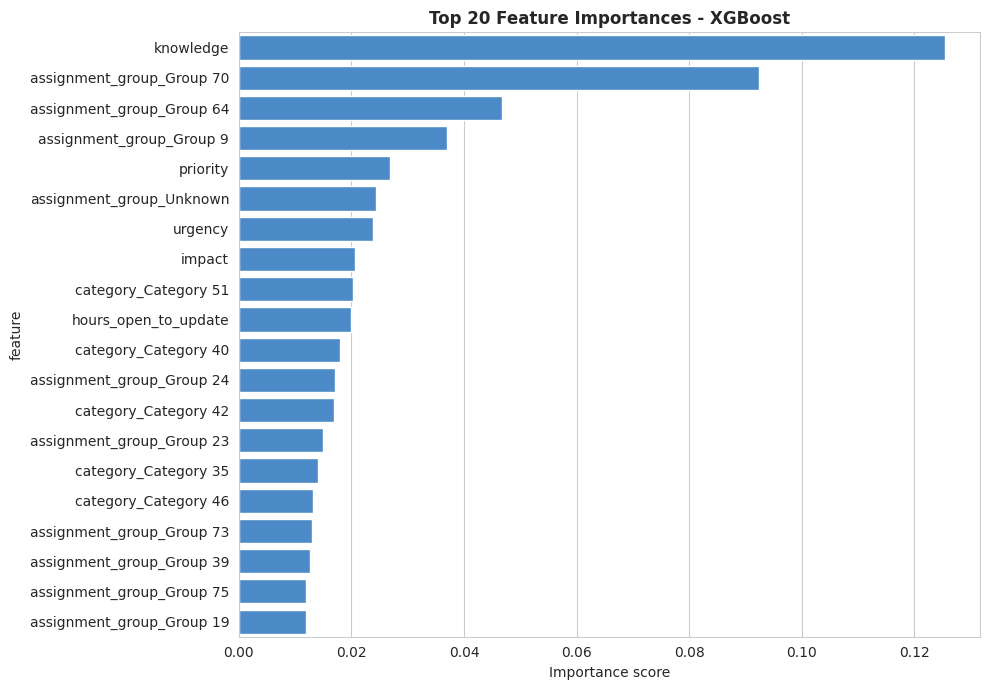

Top 10 most important features:
                  feature  importance
                knowledge    0.125420
assignment_group_Group 70    0.092456
assignment_group_Group 64    0.046803
 assignment_group_Group 9    0.037040
                 priority    0.026896
 assignment_group_Unknown    0.024327
                  urgency    0.023796
                   impact    0.020694
     category_Category 51    0.020339
     hours_open_to_update    0.019941

® Verify: priority, impact, urgency, and hours_open_to_update should rank highly.
® If a ticket ID appears: data leakage bug - go back and remove it.


In [ ]:
# Feature importances show which inputs the model relies on most.
# If row IDs or leaky columns appear here, you have a bug.
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, x='importance', y='feature', color='#378ADD')
plt.title('Top 20 Feature Importances - XGBoost', fontweight='bold')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance_df.head(10).to_string(index=False))
print('\n® Verify: priority, impact, urgency, and hours_open_to_update should rank highly.')
print('® If a ticket ID appears: data leakage bug - go back and remove it.')

Calculating and visualizing the feature importances from the trained XGBoost model. Displaying the top 20 most influential features in a bar plot, helping to understand which input variables the model relies on most for its predictions and to identify any potential data leakage.

## Cell 21 - SHAP values for model explainability

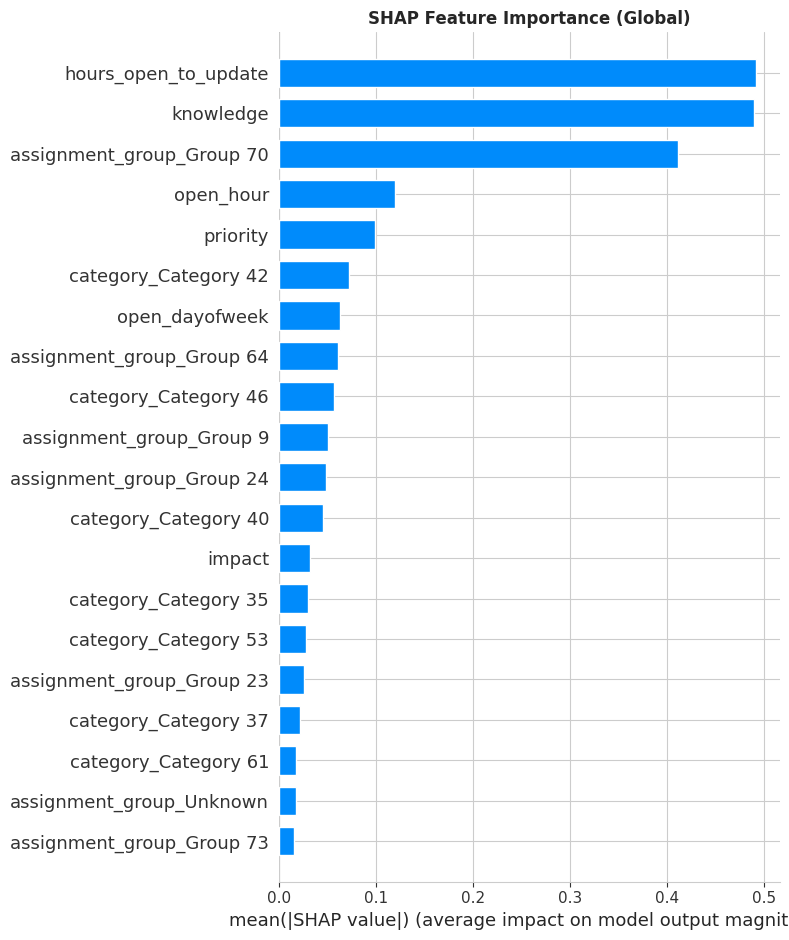

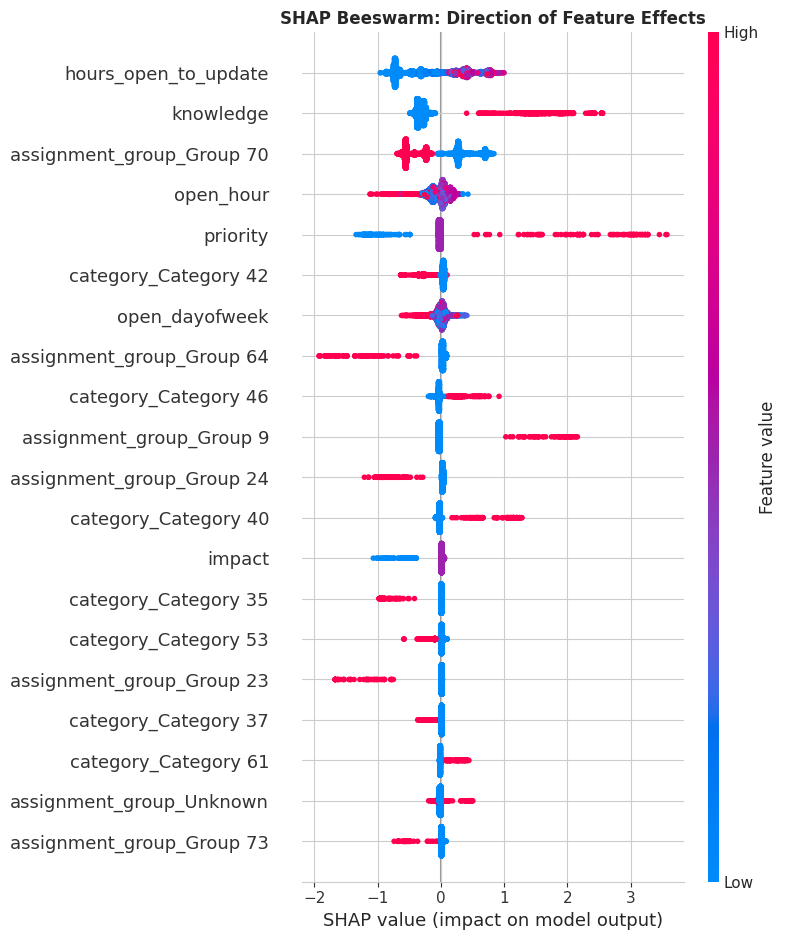

Red dots: high feature value pushes toward breach (positive SHAP)
Blue dots: high feature value pushes toward met SLA (negative SHAP)


In [ ]:
# SHAP explains not just WHICH features matter but HOW they push each prediction.
# Red = pushes toward breach. Blue = pushes toward met SLA.
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot: global feature importance with direction
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=list(X.columns),
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Global)', fontweight='bold')
plt.tight_layout()
plt.show()

# Beeswarm plot: direction of effect
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=list(X.columns),
                  show=False)
plt.title('SHAP Beeswarm: Direction of Feature Effects', fontweight='bold')
plt.tight_layout()
plt.show()

print('Red dots: high feature value pushes toward breach (positive SHAP)')
print('Blue dots: high feature value pushes toward met SLA (negative SHAP)')

Using SHAP (SHapley Additive exPlanations) to interpret the XGBoost model's predictions. Generating a summary plot to show global feature importance and a beeswarm plot to illustrate how individual feature values influence the model's output for each prediction, with red indicating a push towards breach and blue towards met SLA.

In [ ]:
summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',
     'Recall': recall_score(y_test, y_pred_lr),
     'Precision': precision_score(y_test, y_pred_lr),
     'F1': f1_score(y_test, y_pred_lr),
     'AUC-ROC': roc_auc_score(y_test, y_prob_lr)},
    {'Model': 'XGBoost',
     'Recall': recall_score(y_test, y_pred_xgb),
     'Precision': precision_score(y_test, y_pred_xgb),
     'F1': f1_score(y_test, y_pred_xgb),
     'AUC-ROC': roc_auc_score(y_test, y_prob_xgb)},
])

for col in ['Recall','Precision','F1','AUC-ROC']:
    summary[col] = summary[col].round(3)

print('=== Final Model Comparison ===')
print(summary.to_string(index=False))
print()

winner = summary.loc[summary['Recall'].idxmax(), 'Model']
print(f'Selected model for deployment: {winner}')
print('Reason: highest recall = fewest missed SLA breaches = primary business objective')

=== Final Model Comparison ===
                         Model  Recall  Precision    F1  AUC-ROC
Logistic Regression (baseline)   0.671      0.604 0.636    0.794
                       XGBoost   0.779      0.586 0.669    0.817

Selected model for deployment: XGBoost
Reason: highest recall = fewest missed SLA breaches = primary business objective


Summarizing and comparing the performance metrics of both the Logistic Regression and XGBoost models on the test set. Identifying the 'winner' model based on the highest recall score, justifying the choice for deployment by aligning it with the primary business objective of minimizing missed SLA breaches.

In [ ]:
import joblib

# Save model, scaler, and feature list together
artefacts = {
    'model': xgb,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'threshold': float(best['threshold']), # the tuned recall threshold
    'model_version': 'xgb_v1.0',
}

joblib.dump(artefacts, 'sla_breach_model.pkl')

# Download from Colab to your local machine
from google.colab import files
files.download('sla_breach_model.pkl')

print('Model saved as sla_breach_model.pkl')
print('This file contains: model + scaler + feature list + threshold')
print('Phase 2 will wrap this into a FastAPI endpoint for n8n integration.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved as sla_breach_model.pkl
This file contains: model + scaler + feature list + threshold
Phase 2 will wrap this into a FastAPI endpoint for n8n integration.


Serializing and saving the trained XGBoost model, the StandardScaler, the list of feature names, the optimized recall threshold, and a model version into a single `.pkl` file using `joblib`. This package allows for easy deployment and future use of the model, enabling download from Colab for integration into other systems.